## **Multiple linear regression model**
Linear regression remains one of the most widely used methods for predictive modeling in finance. In this small exercise, I develop a multiple linear regression model that leverages a range of global market indices to forecast the price change of an S&P 500 ETF. Beyond constructing the predictive model, I also assess its performance using standard evaluation metrics, offering insights into both model effectiveness and real-world trading potential.

In [6]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
# import all stock market data into DataFrames
aord = pd.read_csv('ALLOrdinary.csv', index_col=0)
nikkei = pd.read_csv('Nikkei225.csv', index_col=0)
hsi = pd.read_csv('HSI.csv', index_col=0)
daxi = pd.read_csv('DAXI.csv', index_col=0)
cac40 = pd.read_csv('CAC40.csv', index_col=0)
sp500 = pd.read_csv('SP500.csv', index_col=0)
dji = pd.read_csv('DJI.csv', index_col=0)
nasdaq = pd.read_csv('nasdaq_composite.csv', index_col=0)
spy = pd.read_csv('SPY.csv', index_col=0)

In [8]:
spy.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2008-01-02,146.529999,146.990005,143.880005,144.929993,116.593864,204935600
2008-01-03,144.910004,145.490005,144.070007,144.860001,116.537567,125133300
2008-01-04,143.339996,143.440002,140.910004,141.309998,113.681671,232330900
2008-01-07,141.809998,142.229996,140.100006,141.190002,113.585121,234991000
2008-01-08,142.080002,142.899994,138.440002,138.910004,111.750923,326365700


### **Step 1: Data Munging**

In [9]:
# build the trading model DataFrame
indicepanel = pd.DataFrame(index=spy.index)

# target variable and lag
indicepanel['spy'] = spy['Open'].shift(-1) - spy['Open']
indicepanel['spy_lag1'] = indicepanel['spy'].shift(1)
indicepanel['Price'] = spy['Open']

# define market indices and their corresponding data sources and logic
open_diff_indices = {
    'sp500': sp500, 'nasdaq': nasdaq, 'dji': dji,
    'cac40': cac40, 'daxi': daxi
}

close_open_diff_indices = {
    'aord': aord, 'hsi': hsi, 'nikkei': nikkei
}

# compute open-to-open returns
for name, df in open_diff_indices.items():
    indicepanel[name] = df['Open'] - df['Open'].shift(1)

# compute intraday returns (close - open)
for name, df in close_open_diff_indices.items():
    indicepanel[name] = df['Close'] - df['Open']


In [25]:
# save the consolidated dataframe
indicepanel.to_csv("indicepanel.csv", index=False)
indicepanel.head()

,spy,spy_lag1,Price,sp500,nasdaq,dji,cac40,daxi,aord,hsi,nikkei
Date,,,,,,,,,,,
2008-01-04,-1.529998,-1.570008,143.339996,-3.540039,-40.879883,2.43945,5.489746,-27.990235,-2.300293,515.349609,-464.320313
2008-01-07,0.270004,-1.529998,141.809998,-29.940064,-56.930176,-245.40918,-111.689941,-102.709961,-27.500000,216.951171,-48.830078
2008-01-08,-2.990006,0.270004,142.080002,1.640015,-7.179931,19.75000,44.509766,33.680176,-33.899902,-354.060547,99.370117
2008-01-09,0.589997,-2.990006,139.089996,-25.459961,-63.119873,-230.69043,-17.109864,-5.270020,-12.900390,768.359375,234.450195
2008-01-10,1.100006,0.589997,139.679993,16.530029,8.270019,142.90039,9.140137,-40.120117,-100.200196,-195.560547,-158.209961


In [11]:
# lets check whether we have NaN values in indicepanel
indicepanel.isnull().sum()

,0
spy,1
spy_lag1,1
Price,0
sp500,1
nasdaq,1
dji,1
cac40,30
daxi,53
aord,319
hsi,121


In [12]:
# forward-fill missing values and drop any remaining NaNs
indicepanel.ffill(inplace=True)
indicepanel.dropna(inplace=True)

In [13]:
# check for Nan values in indicepanel again
indicepanel.isnull().sum()

,0
spy,0
spy_lag1,0
Price,0
sp500,0
nasdaq,0
dji,0
cac40,0
daxi,0
aord,0
hsi,0


In [14]:
# save the processed DataFrame for downstream use
indicepanel.to_csv('/content/indicepanel.csv', index=True)


In [15]:
print(indicepanel.shape)

(2677, 11)


### **Step 2: Data Splitting**

In [16]:
# split data into training and testing sets (1000 samples each from the end of the dataset)
train_set = indicepanel.iloc[-2000:-1000]
test_set = indicepanel.iloc[-1000:]

print(f"Training set shape: {train_set.shape}")
print(f"Testing set shape: {test_set.shape}")


Training set shape: (1000, 11)
Testing set shape: (1000, 11)


### **Step 3: EDA for the Train Data**

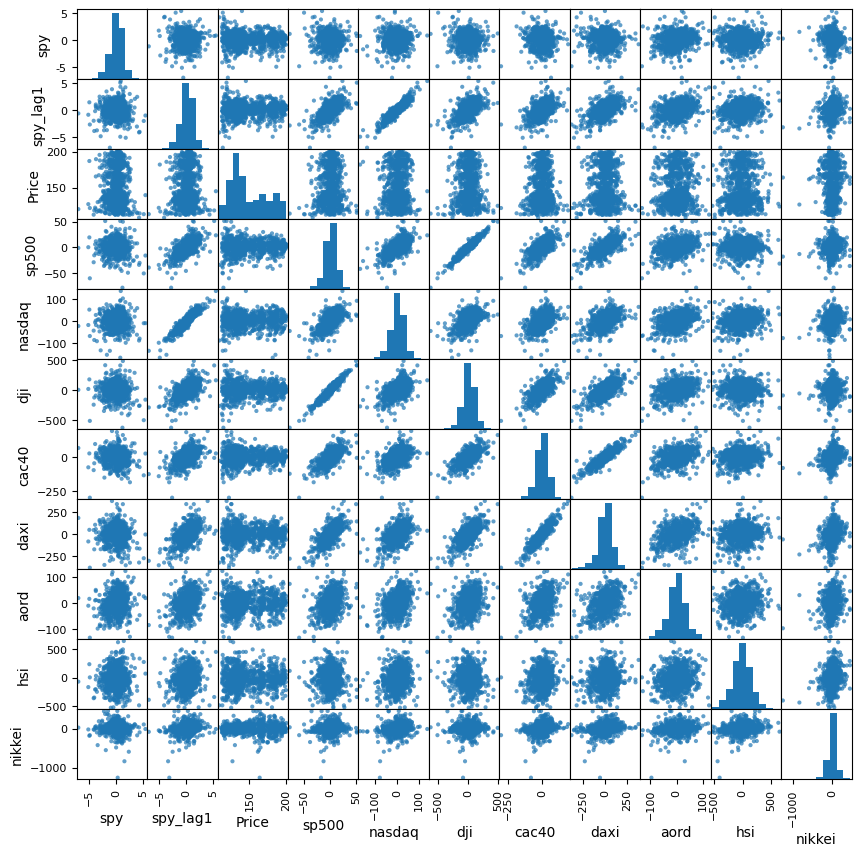

In [17]:
# generate a scatter matrix to visualize pairwise relationships between SPY and other indices
from pandas.plotting import scatter_matrix
scatter_matrix(train_set, figsize=(10, 10), diagonal='hist', alpha=0.7)
plt.show()

### **Step 4: Check for Correlation between SPY and other indeces**

In [18]:
# identify correlation of each feature with SPY's next-day return
correlations = train_set.drop(columns='Price', errors='ignore').corr()['spy'].sort_values(ascending=False)

print("Correlation with SPY's next-day return:")
print(correlations)

Correlation with SPY's next-day return:
spy         1.000000
aord        0.179638
hsi         0.031400
nasdaq      0.012333
spy_lag1   -0.011623
sp500      -0.018632
nikkei     -0.035048
dji        -0.037097
cac40      -0.055304
daxi       -0.069735
Name: spy, dtype: float64


### **Fit the regression model**

In [19]:
# define the regression formula
features = ['spy_lag1', 'sp500', 'nasdaq', 'dji', 'cac40', 'aord', 'daxi', 'nikkei', 'hsi']
formula = 'spy ~ ' + ' + '.join(features)

# fit the multiple linear regression model
model = smf.ols(formula=formula, data=train_set).fit()

# display model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    spy   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     7.962
Date:                Fri, 02 May 2025   Prob (F-statistic):           1.97e-11
Time:                        21:51:08   Log-Likelihood:                -1617.7
No. Observations:                1000   AIC:                             3255.
Df Residuals:                     990   BIC:                             3305.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0836      0.039      2.138      0.0

### **Step 5: Making Predictions**

In [20]:
# generate in-sample and out-of-sample predictions using the fitted model
train_set = train_set.copy()
test_set = test_set.copy()

train_set['predicted_spy'] = model.predict(train_set)
test_set['predicted_spy'] = model.predict(test_set)

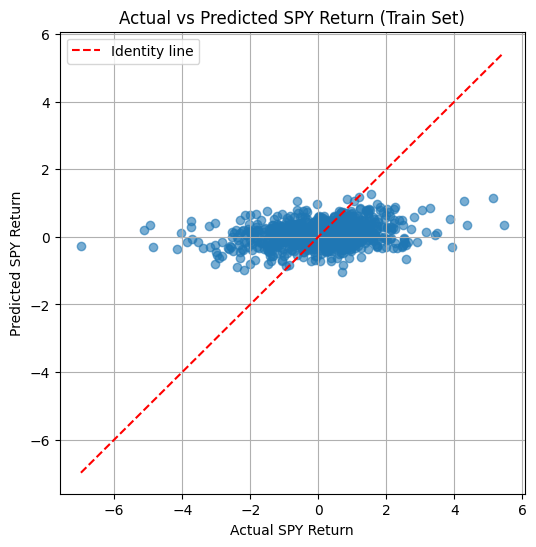

In [21]:
# extract values for plotting
actual = train_set['spy']
predicted = train_set['predicted_spy']

# define limits based on actual + predicted range
plot_min = min(actual.min(), predicted.min())
plot_max = max(actual.max(), predicted.max())

# Create scatter plot and identity line
plt.figure(figsize=(6, 6))
plt.scatter(actual, predicted, alpha=0.6)
plt.plot([plot_min, plot_max], [plot_min, plot_max], 'r--', label='Identity line')
plt.xlabel('Actual SPY Return')
plt.ylabel('Predicted SPY Return')
plt.title('Actual vs Predicted SPY Return (Train Set)')
plt.legend()
plt.grid(True)
plt.show()


### **Step 6: Model Evaluation**

You can measure the performance of the model using some statistical metrics - **RMSE** & **Adjusted $R^2$**

| **Metric**       | **Interpretation**                                                                 |
|------------------|-------------------------------------------------------------------------------------|
| **Adjusted R²**  | Proportion of variance explained, adjusted for number of predictors (penalizes complexity) |
| **RMSE**         | Root Mean Squared Error – average magnitude of prediction error (same units as target `y`) |

In [22]:
def adjusted_metrics(data, model, model_k, yname, is_statsmodels=True):
    """
    Calculate Adjusted R² and RMSE for a regression model.

    Parameters:
    - data: DataFrame with feature and actual target columns
    - model: fitted model (statsmodels or sklearn)
    - model_k: number of predictors
    - yname: name of the target variable column in data
    - is_statsmodels: True if model is from statsmodels, False if sklearn

    Returns:
    - adjusted R², RMSE
    """
    # Predict depending on model type
    if is_statsmodels:
        data['yhat'] = model.predict(data)
    else:
        # Drop target variable if it's in data before prediction
        X = data.drop(columns=[yname])
        data['yhat'] = model.predict(X)

    # Total, explained, and residual sums of squares
    y_actual = data[yname]
    y_pred = data['yhat']
    n = len(data)

    SST = ((y_actual - y_actual.mean())**2).sum()
    SSR = ((y_pred - y_actual.mean())**2).sum()
    SSE = ((y_actual - y_pred)**2).sum()

    r2 = SSR / SST
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - model_k - 1)
    rmse = (SSE / (n - model_k - 1)) ** 0.5

    return adjusted_r2, rmse


In [23]:
def assess_table(test, train, model, model_k, yname, is_statsmodels=True):
    """
    Evaluate and compare model performance on training and test data.

    Parameters:
    - test: Test set DataFrame
    - train: Train set DataFrame
    - model: Fitted model (statsmodels or sklearn)
    - model_k: Number of predictors
    - yname: Target variable name
    - is_statsmodels: True if using statsmodels model, False if sklearn

    Returns:
    - DataFrame with Adjusted R² and RMSE for both Train and Test
    """
    r2_test, rmse_test = adjusted_metrics(test, model, model_k, yname, is_statsmodels)
    r2_train, rmse_train = adjusted_metrics(train, model, model_k, yname, is_statsmodels)

    assessment = pd.DataFrame(index=['Adjusted R²', 'RMSE'], columns=['Train', 'Test'])
    assessment['Train'] = [r2_train, rmse_train]
    assessment['Test'] = [r2_test, rmse_test]

    return assessment


In [24]:
# get the assessment table for the model
metrics_table = assess_table(test_set, train_set, model, model_k=9, yname='spy', is_statsmodels=True)
print(metrics_table)


                Train      Test
Adjusted R²  0.059020  0.067248
RMSE         1.226068  1.701291
